# 🚀 Linear Regression Assignment: California Housing

Welcome to your Linear Regression assignment! In this notebook, you will apply what you've learned to a real-world dataset: predicting house prices in California.

### 🎯 Objective:
Build a regression model to predict the median house value for California districts based on various features (like median income, number of rooms, etc.).


---
## 📦 Step 0: Imports
Import the necessary libraries for data manipulation, visualization, and machine learning.

In [2]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler
# TODO: Import LinearRegression, metrics (mean_absolute_error, mean_squared_error, r2_score)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your scikit-learn imports below:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline




---
## 1️⃣ Part 1: Data Loading & Overview
We will use the California Housing dataset built into Scikit-Learn.

In [7]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
california = fetch_california_housing(as_frame=True) # We got the output in dataframe format
df = california.frame # We took whole dataset and stored it in pandas frames called df 

# TODO: Display the first 5 rows of the dataframe

df.head()
# X will have 8 columns 
# y will have 1 ie Medhouseval

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**💡 Hint:** 
- Use `df.info()` to check for any missing values and see the data types.
- Use `df.describe()` to get a statistical summary of the features.

Our **Target Variable** is `MedHouseVal` (Median house value in $100,000s).

In [10]:
# TODO: Check data info and basic statistics
df.info() # Identity total rows,columns,missing values,data types and memory usage. 
df.describe() 


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


---
## 2️⃣ Part 2: Exploratory Data Analysis (EDA)
Before training a model, it's crucial to understand the data's distribution and relationships.

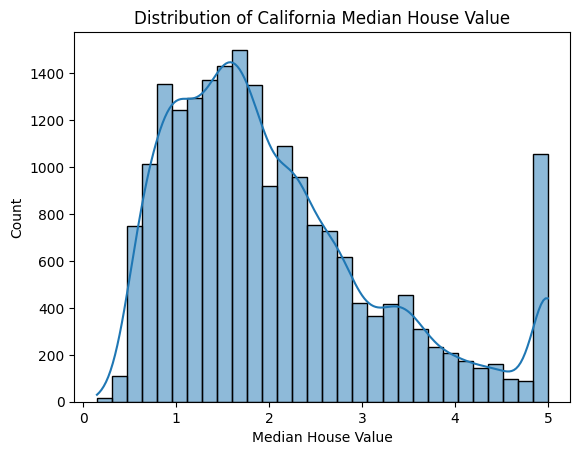

In [19]:
# TODO: Plot a histogram of the target variable (MedHouseVal)
# Hint: sns.histplot(df['MedHouseVal'],kde=True,bins=30)

import seaborn as sns

sns.histplot(df["MedHouseVal"], bins=30,kde=True) # Selected target variable which we identified earlier, added smooth curve,splitted data into 30 group
plt.xlabel("Median House Value")
plt.title("Distribution of California Median House Value")
plt.show()

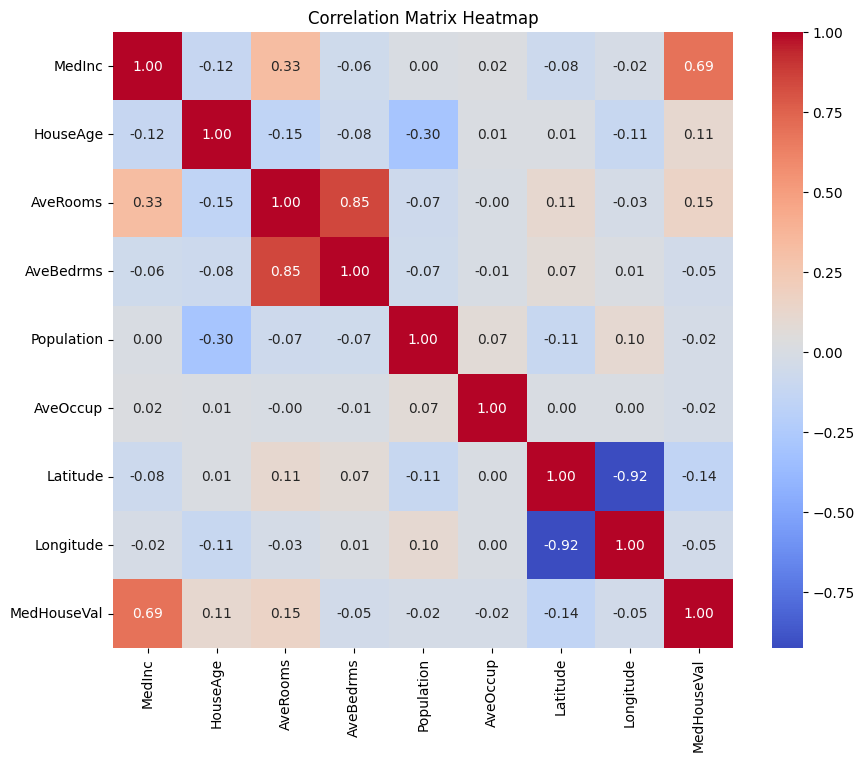

In [ ]:
# TODO: Plot a correlation matrix heatmap to see which features correlate most with MedHouseVal
# Hint: plt.figure(figsize=(10, 8))
# Hint: sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

# Compute correlation matrix
corr_matrix = df.corr() # Calculates orrelation between all pair of columns

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

# Medinc has storagest positive correlation 
# Longtitude and lattitude has strongest negative correlation

**❓ Question:** Based on the correlation matrix, which feature has the strongest positive correlation with the house value? Which one has the strongest negative correlation?

---
## 3️⃣ Part 3: Data Preprocessing
Now, let's prepare the data for our machine learning model.

In [ ]:
# 1. Separate features (X) and target (y)
X = df.drop("MedHouseVal", axis=1) # removed target columns and we are keeping rest of the columns , x is input
y = df["MedHouseVal"]

# TODO: 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Confirmed every row has matching value in y
print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # out of 20640 rows we will traing 80% is 16512 rows, rest will be test

(20640, 8)
(20640,)


**⚠️ Important:** Notice that features like `MedInc` (income) and `Population` are on completely different scales. We need to standardize them!

In [ ]:
# TODO: 3. Scale the features using StandardScaler
# Hint: scaler = StandardScaler()
# Hint: X_train_scaled = scaler.fit_transform(X_train)
# Hint: X_test_scaled = scaler.transform(X_test)



---
## 4️⃣ Part 4: Model Training
Time to train the Linear Regression model!

In [ ]:
# TODO: Initialize and train the Linear Regression model
# Hint: lin_reg = LinearRegression()
# Hint: lin_reg.fit(X_train_scaled, y_train)



---
## 5️⃣ Part 5: Model Evaluation
Let's test our model on the unseen Test data and see how well it performs.

In [ ]:
# TODO: Make predictions on the scaled test set
# Hint: y_pred = lin_reg.predict(X_test_scaled)

# TODO: Calculate and print MAE, RMSE, and R2 Score
# Hint: mae = mean_absolute_error(y_test, y_pred)
#       rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
#       r2 = r2_score(y_test, y_pred)



---
## 🌟 Bonus / Advanced Challenge
Can you improve the error? Try using **Ridge** or **Lasso** regression to see if the R2 score goes up, or identify which features get reduced to 0 by Lasso!


In [ ]:
# Try Ridge or Lasso Regression here:

